# 第四问：联合选择结果与图表复现

按顺序运行全部单元格。只读取保存的CSV，不重新预测或调参。下方包含完整Matplotlib源码，与src/plot_analysis.py保持一致。输出中文矢量PDF和PNG。

**信息边界：**评分热图来自每次决策前已结束的历史窗口；全年费用散点和压力日仅用于事后诊断。同起点联合策略预先确定为正式规则，不能按全年图表倒选历史策略。

|风险编号|alpha|kappa|
|---|---:|---:|
|0|0.80|1.00|
|1|0.85|0.80|
|2|0.90|0.70|
|3|0.90|0.80|
|4|0.95|0.60|
|5|0.95|0.70|

图中“4·M”表示风险4配MPC；G表示即时放电，M表示MPC。组合编号从0起：2×风险编号+控制器编号，G为0、M为1。

## 导入、配色与中文字体

In [1]:
from pathlib import Path
import os
import tempfile
os.environ.setdefault('MPLCONFIGDIR',str(Path(tempfile.gettempdir())/'problem4_matplotlib'))
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager, colors

ORDER=['greedy','mpc','layered','joint','official']
NAMES={'greedy':'原G对照','mpc':'原MPC对照','layered':'原分层',
       'joint':'连续联合','official':'同起点联合'}
PALETTE={'greedy':'#9AA5B1','mpc':'#7D91B1','layered':'#475569','joint':'#3B82A0','official':'#D07838'}
RISK_COLORS=['#335C81','#4D9078','#B68D40','#9A6A8D','#D07838','#637D4B']
COMBO_LABELS=[f'{r}·{m}' for r in range(6) for m in ('G','M')]


def style():
    paths=[Path(os.environ.get('PROBLEM4_FONT','C:/Windows/Fonts/msyh.ttc')),
           Path('C:/Windows/Fonts/simhei.ttf')]
    font=next((p for p in paths if p.exists()),None)
    if font is None:raise FileNotFoundError('设置PROBLEM4_FONT为中文TrueType字体路径')
    font_manager.fontManager.addfont(str(font))
    plt.rcParams.update({'font.family':font_manager.FontProperties(fname=str(font)).get_name(),
        'font.size':10,'axes.titlesize':11,'axes.labelsize':10,'legend.fontsize':9,
        'axes.spines.top':False,'axes.spines.right':False,'axes.unicode_minus':False,
        'axes.edgecolor':'#CBD5E1','axes.labelcolor':'#334155','xtick.color':'#475569','ytick.color':'#475569',
        'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white',
        'grid.color':'#E2E8F0','grid.linewidth':.6,'pdf.fonttype':42,'ps.fonttype':42,
        'figure.dpi':110,'savefig.dpi':170,'path.simplify':False})


def read_data(base):
    base=Path(base);out=base/'outputs'
    files={'daily':'daily_summary.csv','summary':'strategy_comparison.csv','monthly':'monthly_comparison.csv',
        'scores':'selection_scores.csv','choices':'selections.csv','joint_choices':'selections_joint_continuous.csv',
        'candidates':'candidate_comparison.csv','dispatch':'dispatch_all_year.csv'}
    data={k:pd.read_csv(out/name) for k,name in files.items()}
    data['daily']=data['daily'][data['daily'].date>='2025-02-01'].copy()
    data['dispatch']=data['dispatch'][data['dispatch'].date>='2025-02-01'].copy()
    return data


def save(fig,out,name):
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    # 连续色条也保持矢量，关闭Matplotlib对色条网格的默认栅格化。
    for artist in fig.findobj():
        if hasattr(artist,'set_rasterized'):artist.set_rasterized(False)
    fig.savefig(out/f'{name}.pdf',metadata={'CreationDate':None,'ModDate':None,'Creator':'4test reproducible plotting'})
    fig.savefig(out/f'{name}.png',metadata={'Software':'4test reproducible plotting'})
    plt.close(fig)


def grid(ax):
    ax.set_axisbelow(True);ax.grid(axis='y',alpha=.85)


def date_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m月'))
    ax.set_xlabel('日期（2025年）')
    ax.set_xlim(pd.Timestamp('2025-02-01'),pd.Timestamp('2025-12-31'))

## 图1：费用拆解与相对节省

In [2]:
def plot_cost_comparison(data,out):
    s=data['summary'].set_index('strategy').loc[ORDER]
    fig,axs=plt.subplots(1,2,figsize=(12,4.5),layout='constrained',gridspec_kw={'width_ratios':[1.25,1]})
    y=np.arange(5)
    axs[0].barh(y,s.planned_cost_yuan/1e4,color='#7694A8',label='正常购电费',height=.6)
    axs[0].barh(y,s.emergency_cost_yuan/1e4,left=s.planned_cost_yuan/1e4,color='#D8A06A',label='五倍紧急购电费',height=.6)
    for i,v in enumerate(s.total_cost_yuan):axs[0].text(v/1e4+3,i,f'{v/1e4:,.2f}',va='center',fontsize=9)
    axs[0].set(yticks=y,yticklabels=[NAMES[k] for k in ORDER],xlabel='费用（万元）',xlim=(0,s.total_cost_yuan.max()/1e4*1.13))
    axs[0].invert_yaxis();axs[0].legend(loc='lower left',bbox_to_anchor=(0,1.01),frameon=False,ncol=2)
    savings=s.savings_vs_layered_yuan/1e4
    axs[1].barh(y,savings,color=[PALETTE[k] for k in ORDER],height=.6)
    for i,v in enumerate(savings):axs[1].annotate(f'{v:+.2f}',(v,i),xytext=(5 if v>=0 else -5,0),
        textcoords='offset points',ha='left' if v>=0 else 'right',va='center',fontsize=9)
    pad=max(abs(savings).max()*.35,.4)
    axs[1].set(yticks=y,yticklabels=[NAMES[k] for k in ORDER],xlabel='相对原分层节省（万元）',xlim=(savings.min()-pad,savings.max()+pad))
    axs[1].axvline(0,color='#64748B',lw=.8);axs[1].invert_yaxis()
    for ax in axs:ax.grid(axis='x',alpha=.6);ax.set_axisbelow(True)
    save(fig,out,'cost_comparison')

## 图2：月度与累计节省

In [3]:
def plot_monthly_cost(data,out):
    fig,axs=plt.subplots(2,1,figsize=(11,7),layout='constrained')
    m=data['monthly'];months=sorted(m.month.unique());x=np.arange(len(months))
    for j,name in enumerate(('joint','official')):
        s=m[m.strategy==name].set_index('month').loc[months]
        axs[0].bar(x+(j-.5)*.35,s.savings_vs_layered_yuan/1e4,.33,color=PALETTE[name],label=NAMES[name])
    axs[0].axhline(0,color='#64748B',lw=.8);axs[0].set(xticks=x,xticklabels=[str(int(z[-2:]))+'月' for z in months],ylabel='每月节省（万元）')
    axs[0].legend(frameon=False,ncol=2);grid(axs[0])
    d=data['daily'].pivot(index='date',columns='strategy',values='total_cost_yuan').sort_index()
    dates=pd.to_datetime(d.index)
    for name in ('greedy','mpc','joint','official'):
        values=(d.layered-d[name]).cumsum()/1e4
        axs[1].plot(dates,values,label=NAMES[name],color=PALETTE[name],lw=1.7 if name=='official' else 1.15)
    axs[1].axhline(0,color='#64748B',lw=.8);axs[1].set_ylabel('累计节省（万元）')
    axs[1].legend(frameon=False,ncol=4);grid(axs[1]);date_axis(axs[1])
    if np.allclose(d.joint,d.official,atol=1e-6,rtol=0):
        axs[1].text(.02,.96,'两种联合结果相同，曲线重合',transform=axs[1].transAxes,va='top',fontsize=9,color='#64748B')
    save(fig,out,'monthly_cost')

## 图3：紧急购电量与实际支付单价

In [4]:
def plot_emergency(data,out):
    fig,axs=plt.subplots(2,1,figsize=(11,7),layout='constrained')
    m=data['monthly'];months=sorted(m.month.unique());x=np.arange(len(months))
    for j,name in enumerate(('layered','joint','official')):
        s=m[m.strategy==name].set_index('month').loc[months]
        axs[0].bar(x+(j-1)*.24,s.emergency_kwh/1e4,.23,color=PALETTE[name],label=NAMES[name])
        axs[1].plot(x,s.average_emergency_price,marker='o',ms=4,color=PALETTE[name],label=NAMES[name])
    for ax in axs:
        ax.set(xticks=x,xticklabels=[str(int(z[-2:]))+'月' for z in months]);grid(ax)
    axs[0].set_ylabel('紧急购电量（万kWh）');axs[0].legend(frameon=False,ncol=3)
    axs[1].set(ylabel='紧急平均支付单价（元/kWh）',xlabel='月份（2025年）')
    save(fig,out,'monthly_emergency')

## 图4：组合选择与第一第二名分差

In [5]:
def plot_selection(data,out):
    fig,axs=plt.subplots(2,1,figsize=(12,7),layout='constrained',gridspec_kw={'height_ratios':[1.6,1]})
    for name in ('layered','joint','official'):
        s=data['daily'][data['daily'].strategy==name]
        combo=s.risk_index*2+(s.controller=='mpc').astype(int)
        axs[0].step(pd.to_datetime(s.date),combo,where='post',label=NAMES[name],color=PALETTE[name],lw=1.3)
    axs[0].set(yticks=range(12),yticklabels=COMBO_LABELS,ylabel='组合：风险编号·控制器')
    axs[0].legend(frameon=False,ncol=3);grid(axs[0]);date_axis(axs[0])
    for name,key in [('joint','joint_choices'),('official','choices')]:
        s=data[key]
        axs[1].plot(pd.to_datetime(s.date),s.runner_up_gap_yuan/1000,'o-',ms=3,lw=1,color=PALETTE[name],label=NAMES[name])
    axs[1].set_ylabel('历史前两名评分差（千元）');grid(axs[1]);date_axis(axs[1])
    save(fig,out,'selection_timeline')

## 图5：全部历史候选评分，不使用未来实际费用排名

In [6]:
def plot_historical_scores(data,out):
    fig,axs=plt.subplots(2,1,figsize=(12,8),layout='constrained')
    grids=[]
    for selector in ('continuous','same_start'):
        p=data['scores'][data['scores'].selector==selector].pivot(index='combo',columns='date',values='score').sort_index()
        grids.append((p-p.min(axis=0))/1000)
    vmax=max(g.to_numpy().max() for g in grids)
    for ax,g,title in zip(axs,grids,['连续联合：各候选距当次最佳的历史分差','同起点联合：各候选距当次最佳的历史分差']):
        mesh=ax.pcolormesh(np.arange(g.shape[1]+1),np.arange(13),g.to_numpy(),cmap='YlGnBu',vmin=0,vmax=vmax,rasterized=False)
        winner=np.argmin(g.to_numpy(),axis=0);ax.scatter(np.arange(len(winner))+.5,winner+.5,s=14,color='#D07838',marker='s')
        ticks=np.arange(0,g.shape[1],6)
        ax.set(yticks=np.arange(12)+.5,yticklabels=COMBO_LABELS,xticks=ticks+.5,
            xticklabels=[str(g.columns[i])[5:] for i in ticks],ylabel='候选组合',xlabel='更新日（月-日）')
        ax.set_title(title,loc='left');ax.invert_yaxis()
    fig.colorbar(mesh,ax=axs,label='历史评分差（千元）；橙点为当次最优',shrink=.85)
    save(fig,out,'historical_scores')

## 图6：参数与控制器交互、历史选择次数

In [7]:
def plot_interaction(data,out):
    s=data['scores'];same=s[s.selector=='same_start']
    g=same[same.controller=='greedy'].pivot(index='risk_index',columns='date',values='score')
    m=same[same.controller=='mpc'].pivot(index='risk_index',columns='date',values='score')
    difference=(g-m)/1000;limit=max(abs(difference.to_numpy()).max(),1e-6)
    fig,axs=plt.subplots(2,1,figsize=(12,7),layout='constrained')
    mesh=axs[0].pcolormesh(np.arange(g.shape[1]+1),np.arange(7),difference.to_numpy(),cmap='BrBG',
        norm=colors.TwoSlopeNorm(vmin=-limit,vcenter=0,vmax=limit),rasterized=False)
    ticks=np.arange(0,g.shape[1],6)
    axs[0].set(yticks=np.arange(6)+.5,yticklabels=range(6),xticks=ticks+.5,
        xticklabels=[str(g.columns[i])[5:] for i in ticks],ylabel='风险参数编号',xlabel='更新日（月-日）')
    axs[0].invert_yaxis();fig.colorbar(mesh,ax=axs[0],label='G评分 − MPC评分（千元）；正值偏向MPC')
    for j,(selector,label,color) in enumerate([('continuous','连续联合',PALETTE['joint']),('same_start','同起点联合',PALETTE['official'])]):
        counts=s[s.selector==selector].groupby('combo').selected.sum().reindex(range(12),fill_value=0)
        axs[1].bar(np.arange(12)+(j-.5)*.35,counts,.33,label=label,color=color)
    axs[1].set(xticks=range(12),xticklabels=COMBO_LABELS,ylabel='被选中次数',xlabel='组合：风险编号·控制器')
    axs[1].legend(frameon=False);grid(axs[1]);save(fig,out,'parameter_controller_interaction')

## 图7：费用与紧急电量的权衡（仅作事后诊断）

In [8]:
def plot_tradeoff(data,out):
    fig,ax=plt.subplots(figsize=(9,6),layout='constrained');c=data['candidates']
    for _,r in c.iterrows():
        marker='o' if r.controller=='greedy' else 'D'
        ax.scatter(r.emergency_kwh/1e4,r.cost_minus_layered_yuan/1e4,marker=marker,s=60,color=RISK_COLORS[int(r.risk_index)],edgecolors='white',lw=.6)
        ax.annotate(COMBO_LABELS[int(r.combo)],(r.emergency_kwh/1e4,r.cost_minus_layered_yuan/1e4),xytext=(5,5),textcoords='offset points',fontsize=8)
    for name,marker in [('layered','s'),('joint','P'),('official','*')]:
        r=data['summary'].set_index('strategy').loc[name]
        ax.scatter(r.emergency_kwh/1e4,-r.savings_vs_layered_yuan/1e4,marker=marker,s=150,color=PALETTE[name],label=NAMES[name],edgecolors='white',lw=.6)
    ax.axhline(0,color='#94A3B8',ls='--',lw=.8);grid(ax)
    ax.set(xlabel='评价期紧急购电量（万kWh）',ylabel='总费用相对原分层的增加（万元）')
    ax.legend(frameon=False);ax.text(.02,.02,'左下更优；圆点=G，菱形=MPC；固定候选全年结果不参与历史选择',transform=ax.transAxes,fontsize=8,color='#64748B')
    save(fig,out,'candidate_tradeoff')

## 图8、9：典型日与压力日的实际物理调度

In [9]:
def plot_dispatch(data,out,date,name):
    s=data['dispatch'][data['dispatch'].date==date];x=s.slot.to_numpy()/6
    fig,axs=plt.subplots(3,1,figsize=(12,8),sharex=True,layout='constrained',gridspec_kw={'height_ratios':[1,1.7,1.2]})
    axs[0].step(np.r_[x,24],np.r_[s.price_yuan_per_kwh,s.price_yuan_per_kwh.iloc[-1]],where='post',color='#475569',lw=1.4)
    axs[0].set_ylabel('电价（元/kWh）')
    for key,label,color in [('load_kwh','负载','#475569'),('pv_kwh','光伏','#BF9D45'),('plan_purchase_kwh','计划购电','#3B82A0')]:
        axs[1].step(x,s[key],where='post',label=label,color=color,lw=1.2)
    axs[1].bar(x,-s.charge_kwh,width=1/6,align='edge',color='#6F9C87',alpha=.65,label='充电（负向）')
    axs[1].bar(x,s.discharge_kwh,width=1/6,align='edge',color='#A693B0',alpha=.5,label='放电')
    axs[1].bar(x,s.emergency_kwh,width=1/6,align='edge',color='#D07838',alpha=.95,label='紧急购电')
    axs[1].set_ylabel('十分钟电量（kWh）');axs[1].legend(frameon=False,ncol=6,loc='upper center')
    soc=np.r_[s.soc_start_kwh,s.soc_end_kwh.iloc[-1]]
    axs[2].plot(np.arange(145)/6,soc,color='#3B82A0',lw=1.5)
    axs[2].fill_between(np.arange(145)/6,1200,soc,color='#3B82A0',alpha=.1)
    for bound in (1200,10800):axs[2].axhline(bound,color='#94A3B8',ls='--',lw=.8)
    axs[2].set(ylabel='储电量（kWh）',xlabel=f'{date} 时刻',ylim=(0,11800),xlim=(0,24),xticks=np.arange(0,25,2))
    for ax in axs:grid(ax)
    save(fig,out,name)

## 图10：全年库存范围

In [10]:
def plot_soc(data,out):
    s=data['dispatch'];g=s.groupby('date').agg(low=('soc_start_kwh','min'),high=('soc_start_kwh','max'),end=('soc_end_kwh','last'))
    # 24:00同样属于当日轨迹边界。
    g.low=np.minimum(g.low,g.end);g.high=np.maximum(g.high,g.end)
    x=pd.to_datetime(g.index)
    fig,ax=plt.subplots(figsize=(12,4.5),layout='constrained')
    ax.fill_between(x,g.low,g.high,color='#3B82A0',alpha=.16,label='日内库存范围')
    ax.plot(x,g.end,color='#3B82A0',lw=1,label='每日24:00库存')
    for bound in (1200,10800):
        ax.axhline(bound,color='#9B7254',ls='--',lw=.8,label=f'{bound} kWh边界')
    ax.set(ylabel='储电量（kWh）',ylim=(0,12000));date_axis(ax);grid(ax)
    ax.legend(frameon=False,ncol=4,loc='upper center');save(fig,out,'soc')

## 全部图表入口

In [11]:
def create_figures(base,output_dir=None):
    style();data=read_data(base);out=Path(output_dir) if output_dir else Path(base)/'figures'
    for function in (plot_cost_comparison,plot_monthly_cost,plot_emergency,plot_selection,
                     plot_historical_scores,plot_interaction,plot_tradeoff):function(data,out)
    plot_dispatch(data,out,'2025-06-21','dispatch_june21')
    stress=data['dispatch'].groupby('date').emergency_kwh.sum().idxmax()
    plot_dispatch(data,out,stress,'dispatch_stress_day');plot_soc(data,out)
    from pypdf import PdfReader
    paths=sorted(out.glob('*.pdf'))
    assert len(paths)==10
    for path in paths:
        pdf=PdfReader(path);assert len(pdf.pages)==1
        objects=pdf.pages[0].get('/Resources',{}).get('/XObject',{})
        if hasattr(objects,'get_object'):objects=objects.get_object()
        assert all(obj.get_object().get('/Subtype')!='/Image' for obj in objects.values()),path.name
    return paths

## 定位数据与输出目录

通常从4test或notebooks目录运行。环境变量仅供验收时将复现图写入独立目录，正常使用无需设置。

In [12]:
start=Path.cwd().resolve()
candidates=[p for parent in (start,*start.parents) for p in (parent,parent/'4test')]
BASE=next(p for p in candidates if (p/'outputs/selection_scores.csv').exists())
FIGURES=Path(os.environ.get('PROBLEM4_FIGURE_DIR',str(BASE/'figures')))
style()
data=read_data(BASE)
display(data['summary'][['label','total_cost_yuan','savings_vs_layered_yuan','emergency_kwh']])

,label,total_cost_yuan,savings_vs_layered_yuan,emergency_kwh
0,原G对照,1.462834e+07,-38247.518164,101160.208625
1,原MPC对照,1.458069e+07,9406.177687,105639.676533
2,原分层选择,1.459009e+07,0.000000,104472.710978
3,连续联合选择,1.458049e+07,9602.678122,103667.711485
4,同起点联合选择（正式）,1.458049e+07,9602.678122,103667.711485


## 费用构成与相对节省

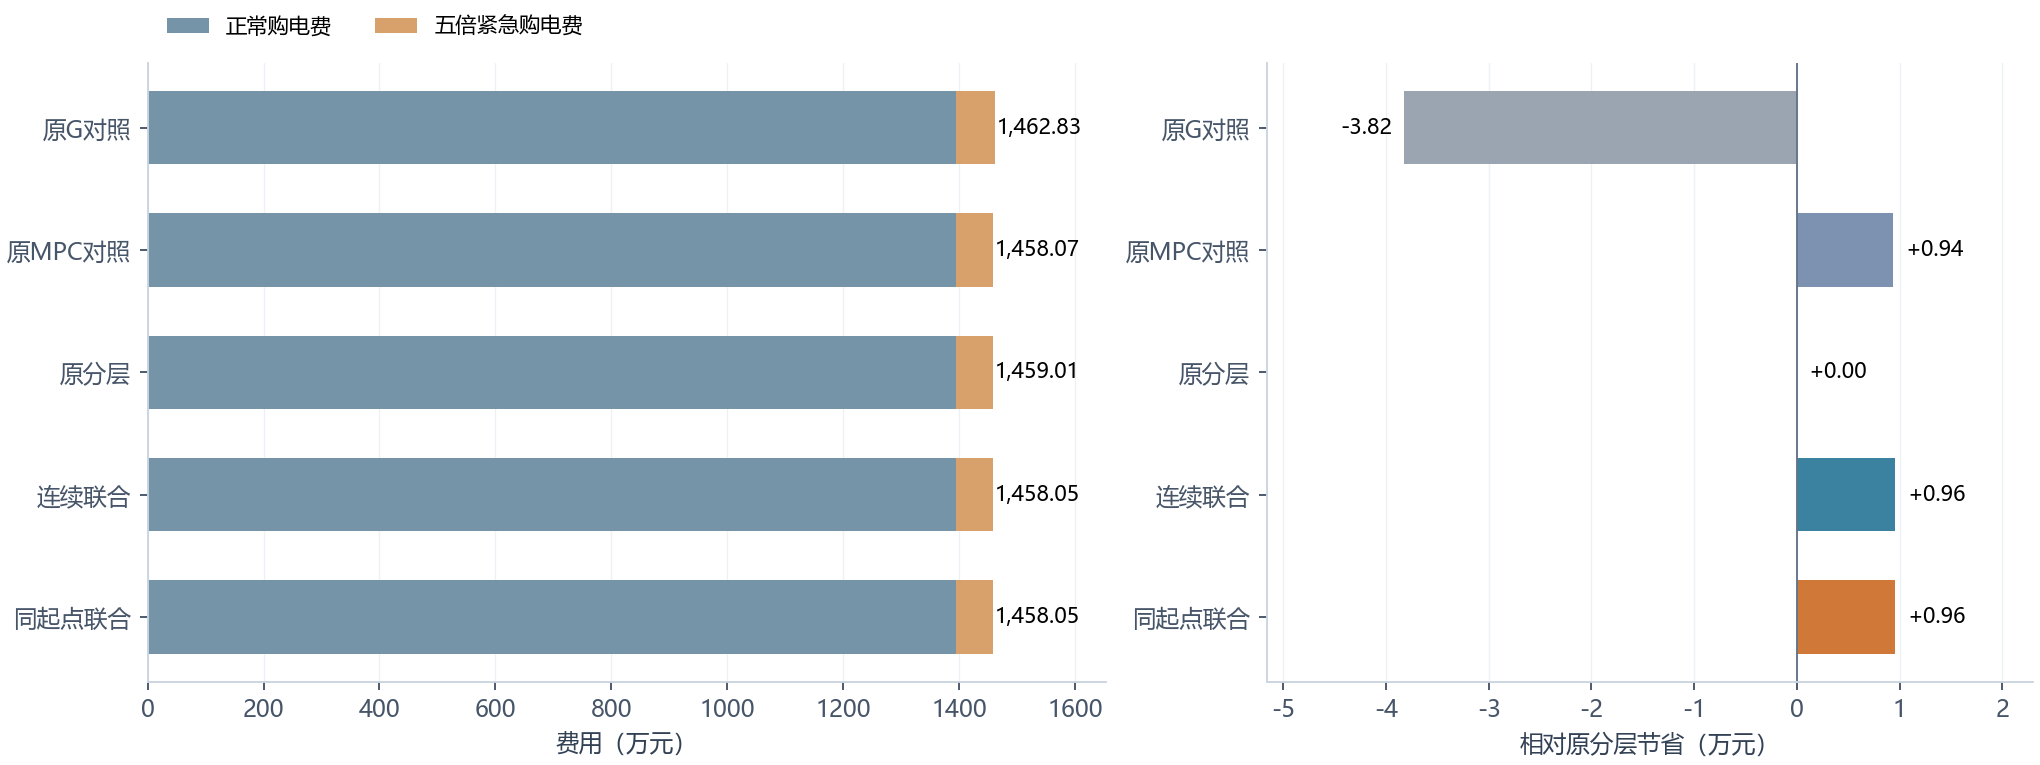

In [13]:
plot_cost_comparison(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'cost_comparison.png')))

## 月度和累计节省

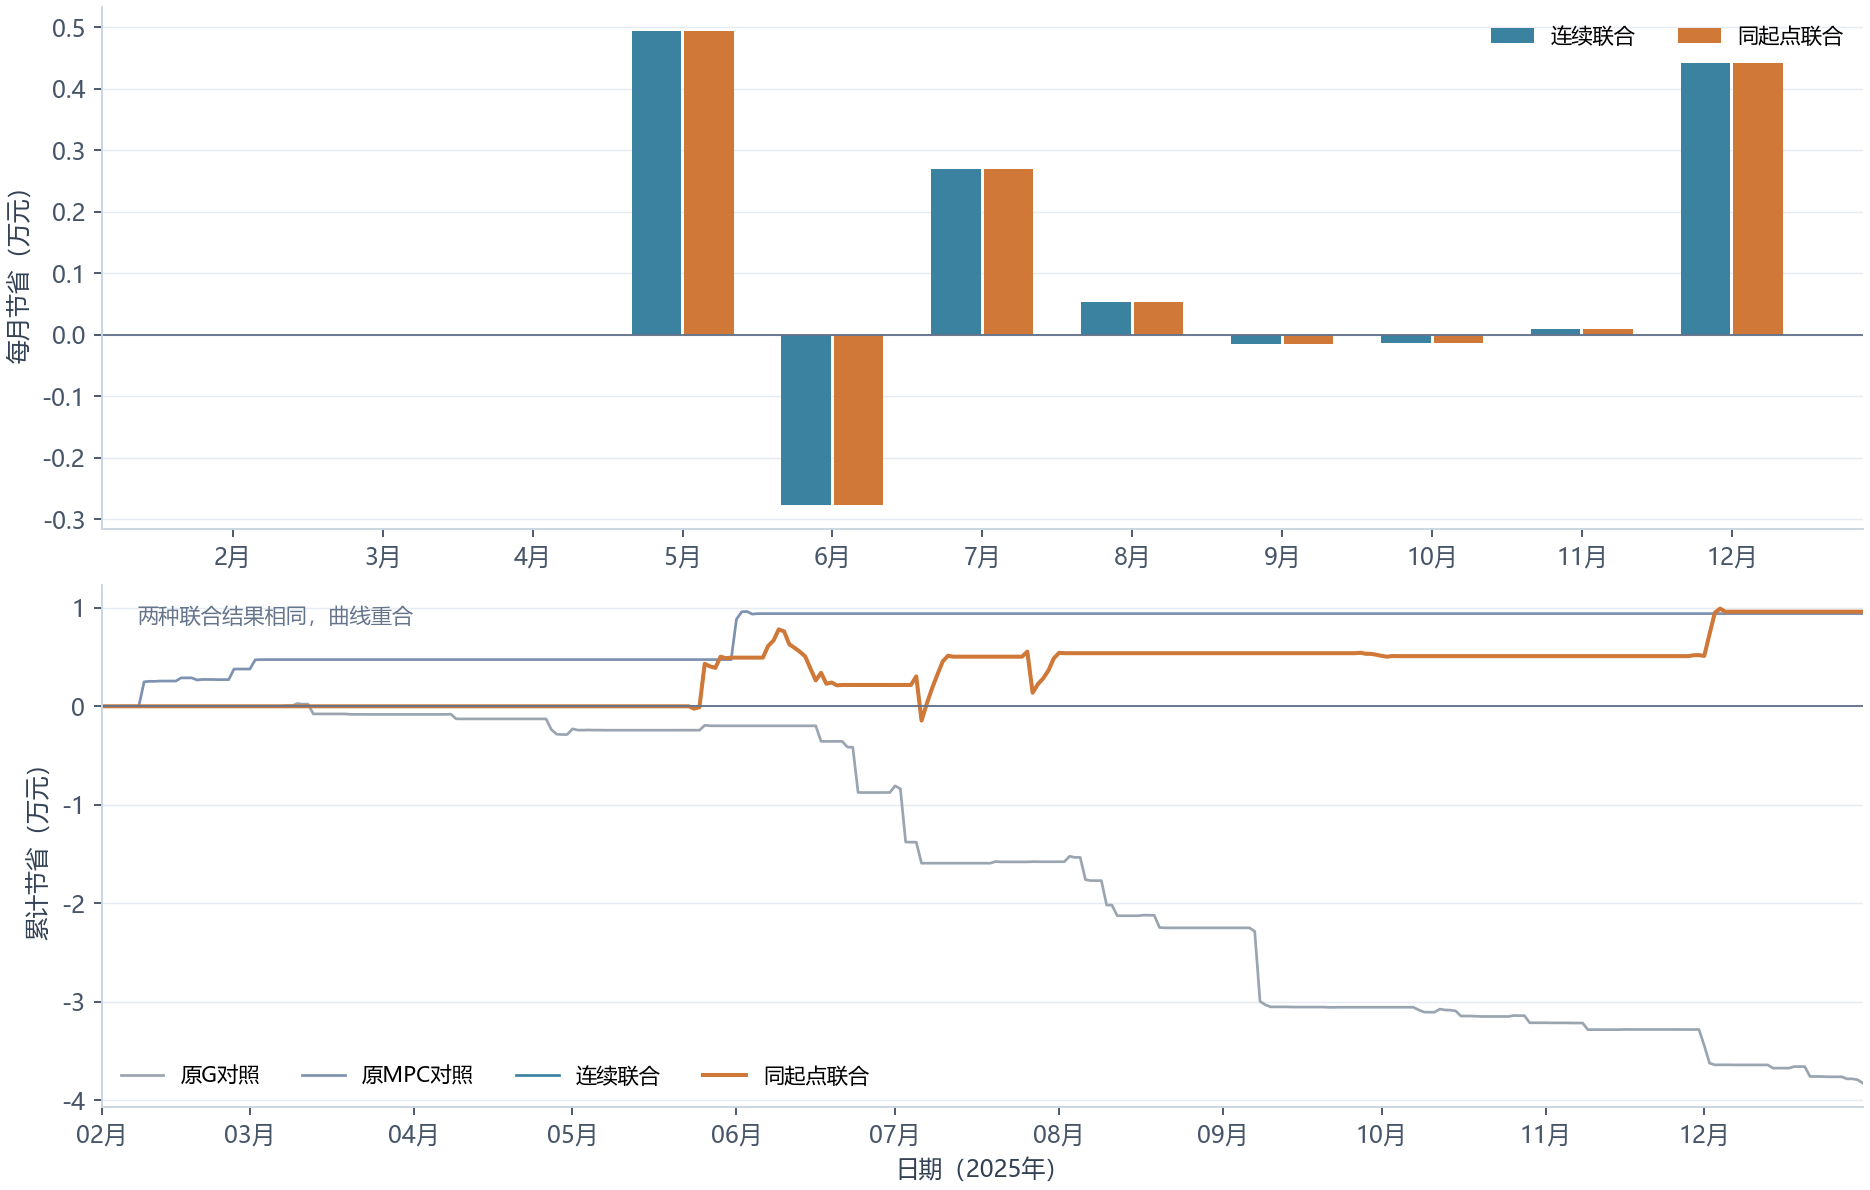

In [14]:
plot_monthly_cost(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'monthly_cost.png')))

## 紧急电量和支付单价

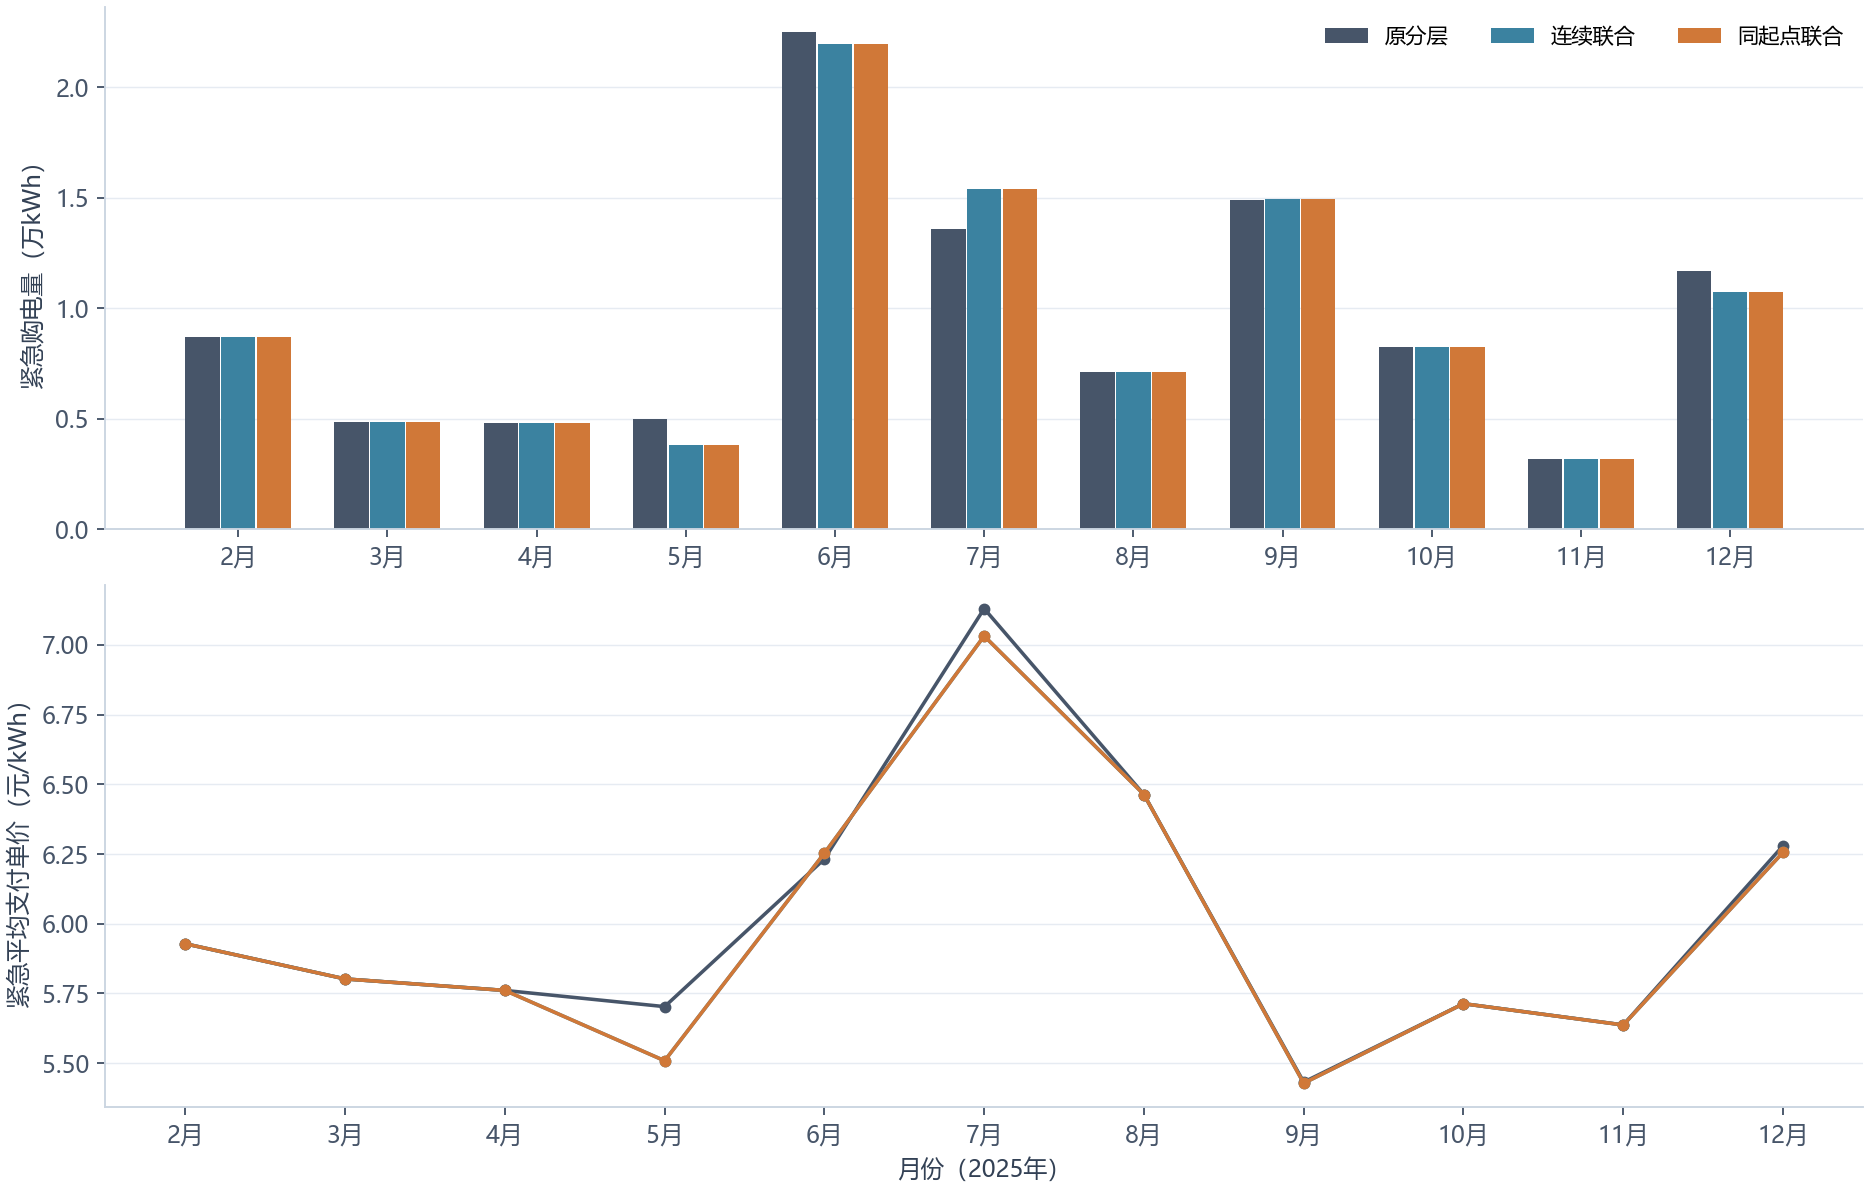

In [15]:
plot_emergency(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'monthly_emergency.png')))

## 组合选择轨迹

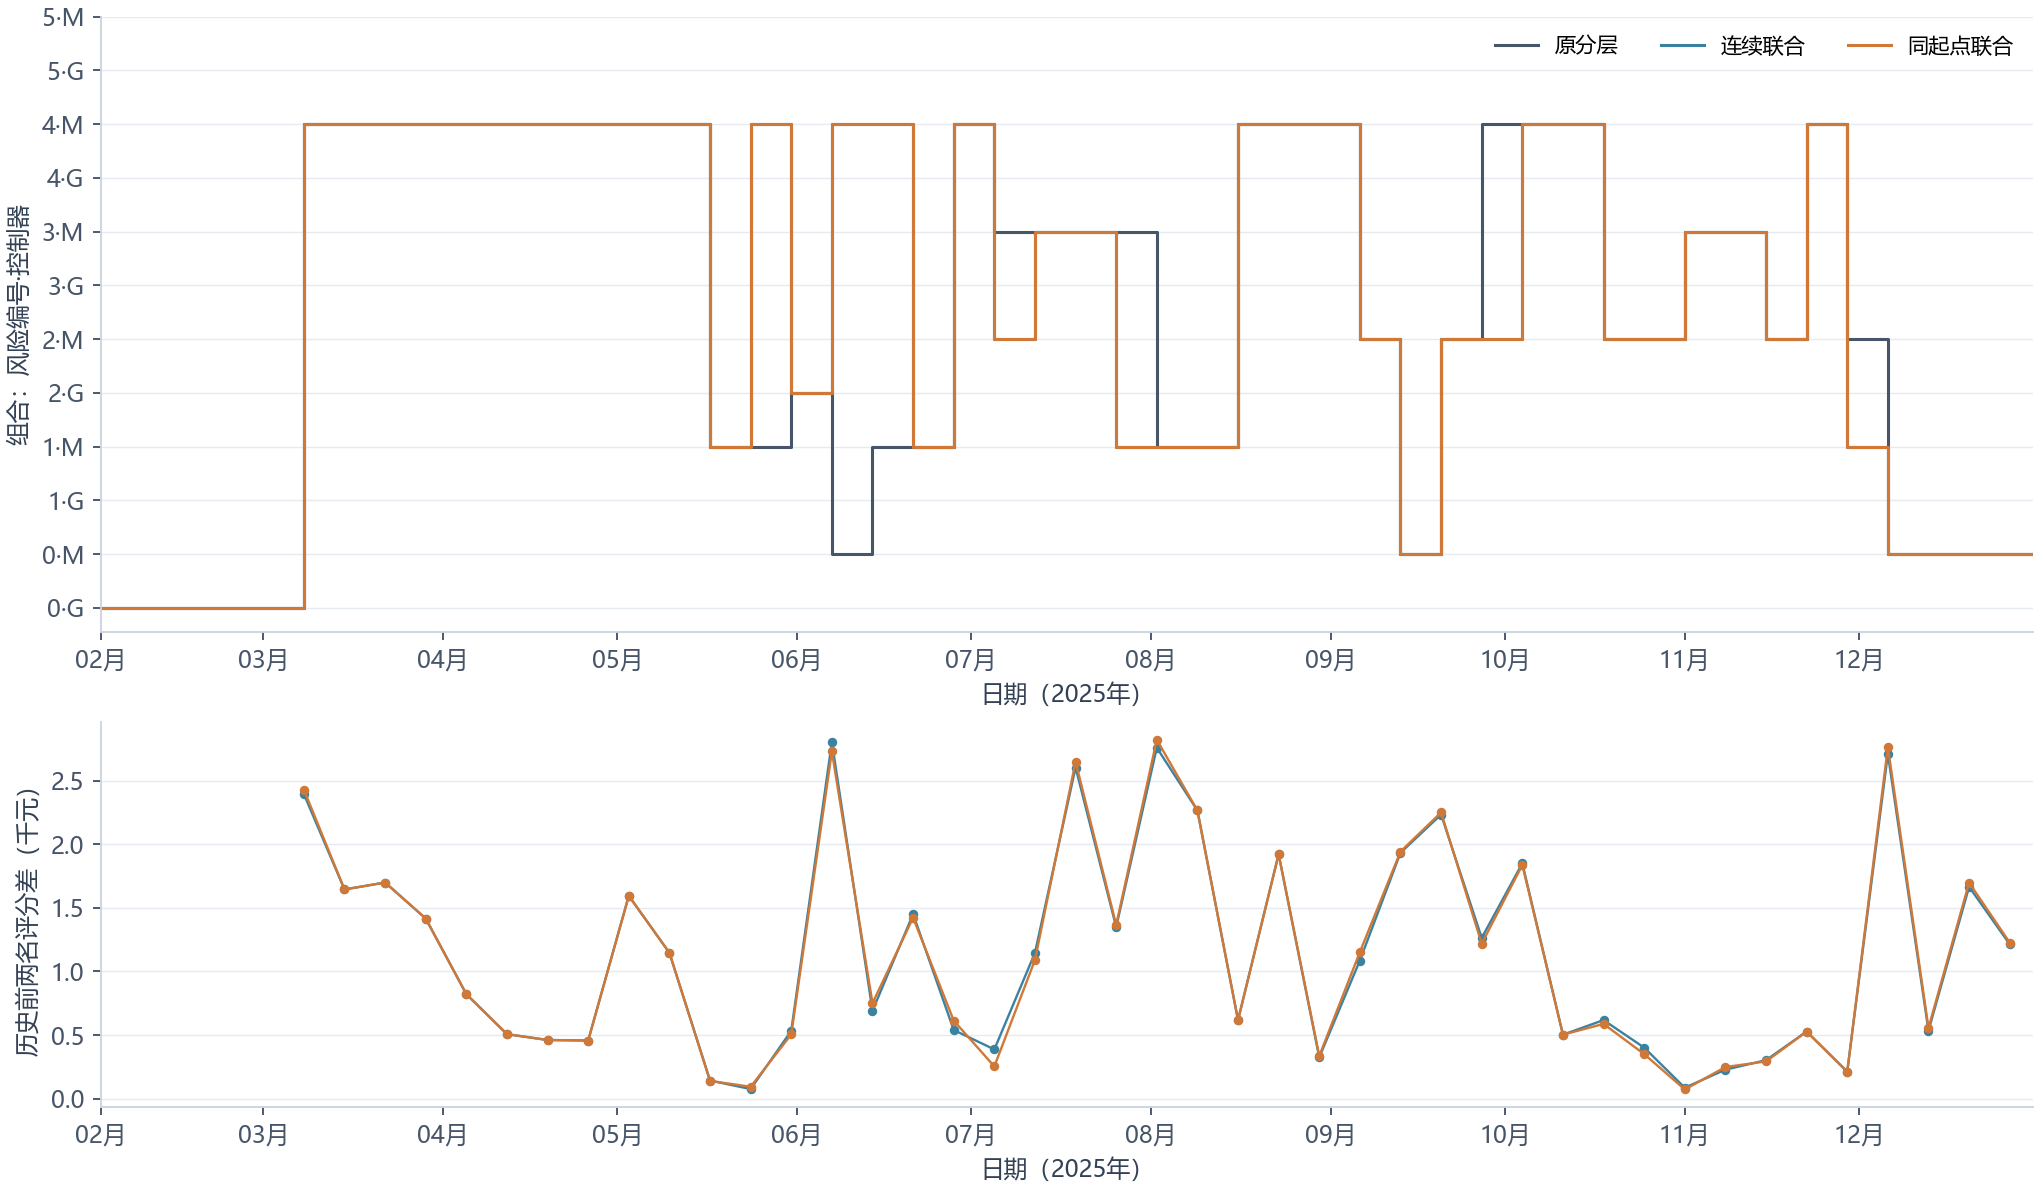

In [16]:
plot_selection(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'selection_timeline.png')))

## 历史评分全貌

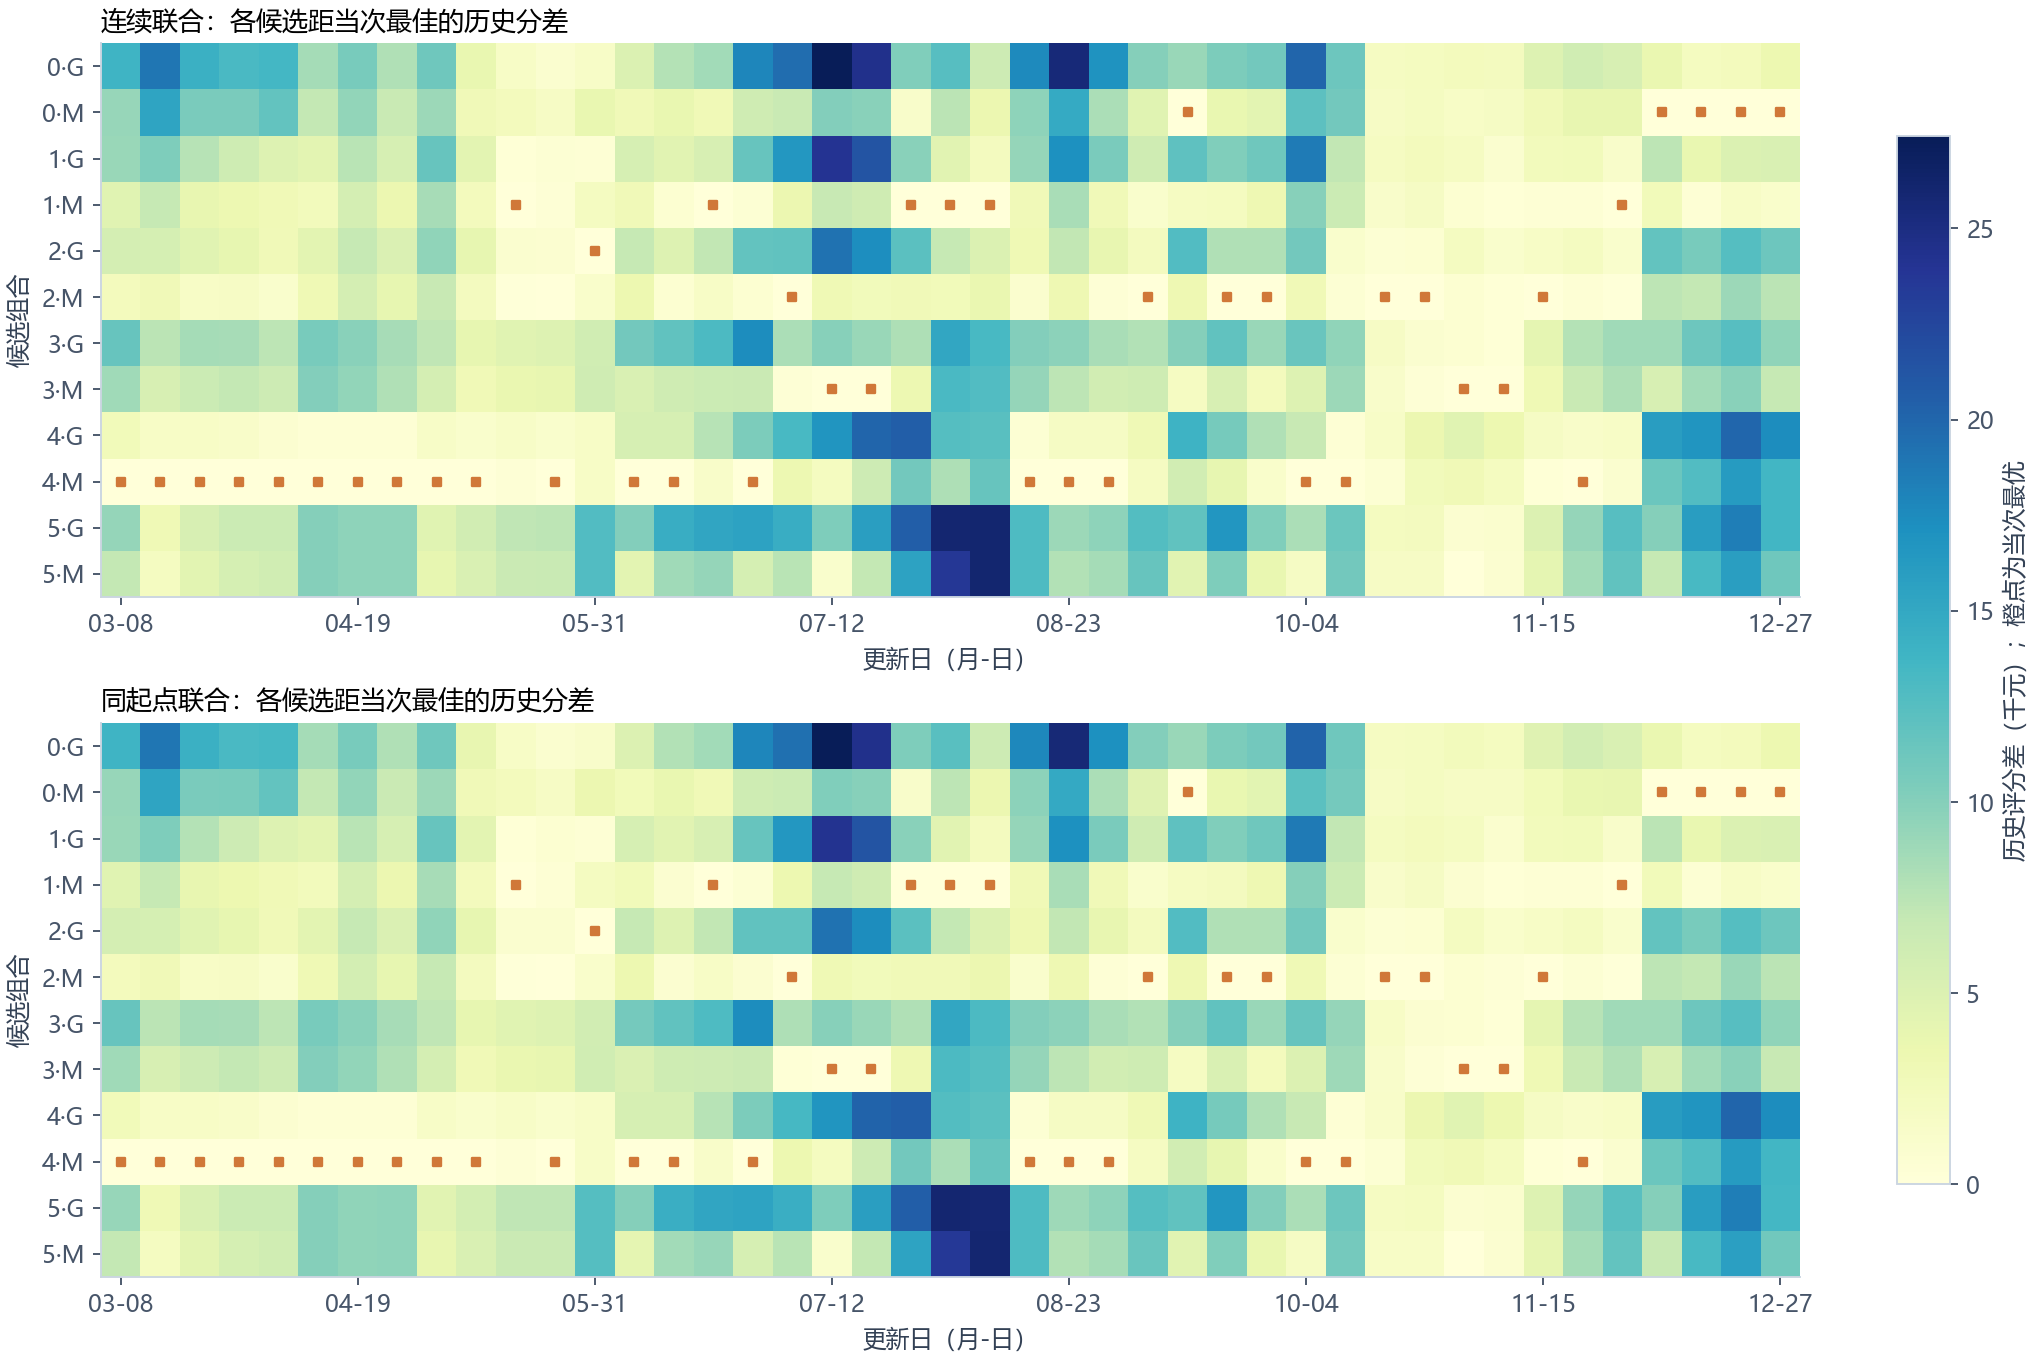

In [17]:
plot_historical_scores(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'historical_scores.png')))

## 参数与控制器交互

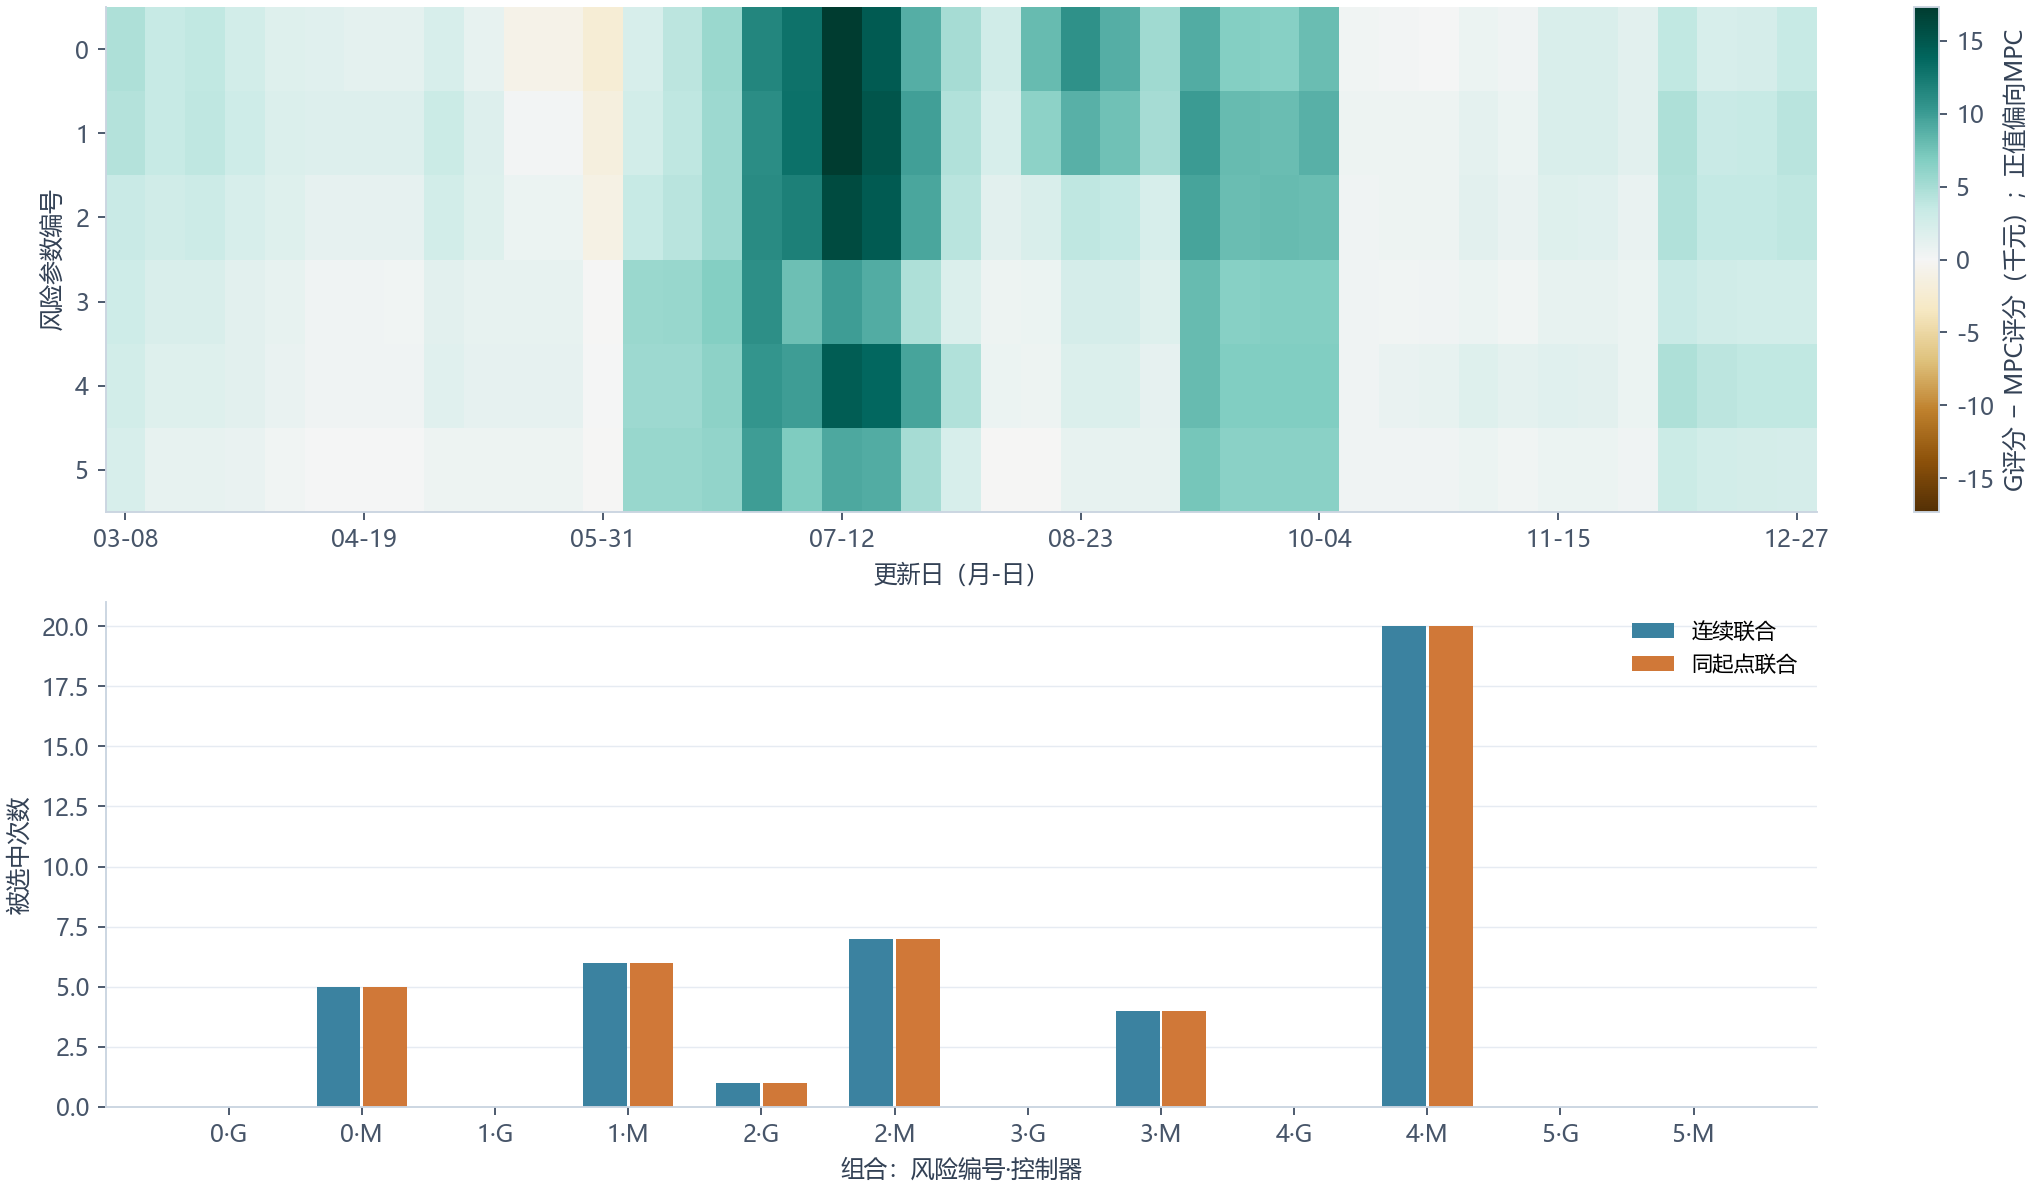

In [18]:
plot_interaction(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'parameter_controller_interaction.png')))

## 事后费用与电量权衡

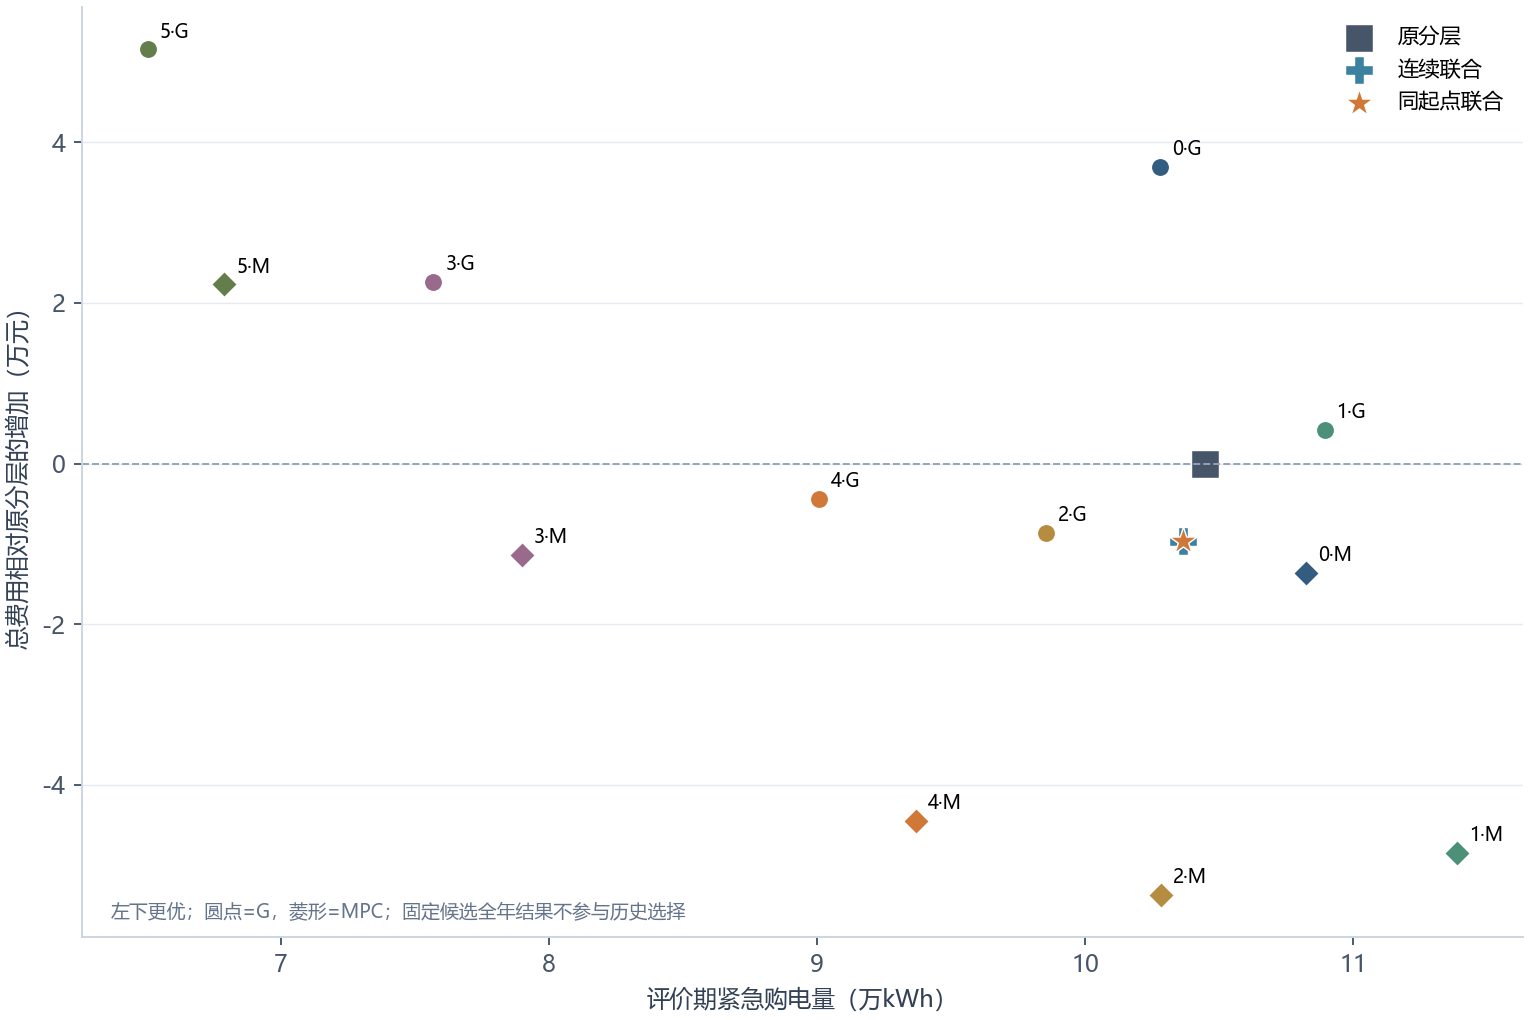

In [19]:
plot_tradeoff(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'candidate_tradeoff.png')))

## 6月21日调度

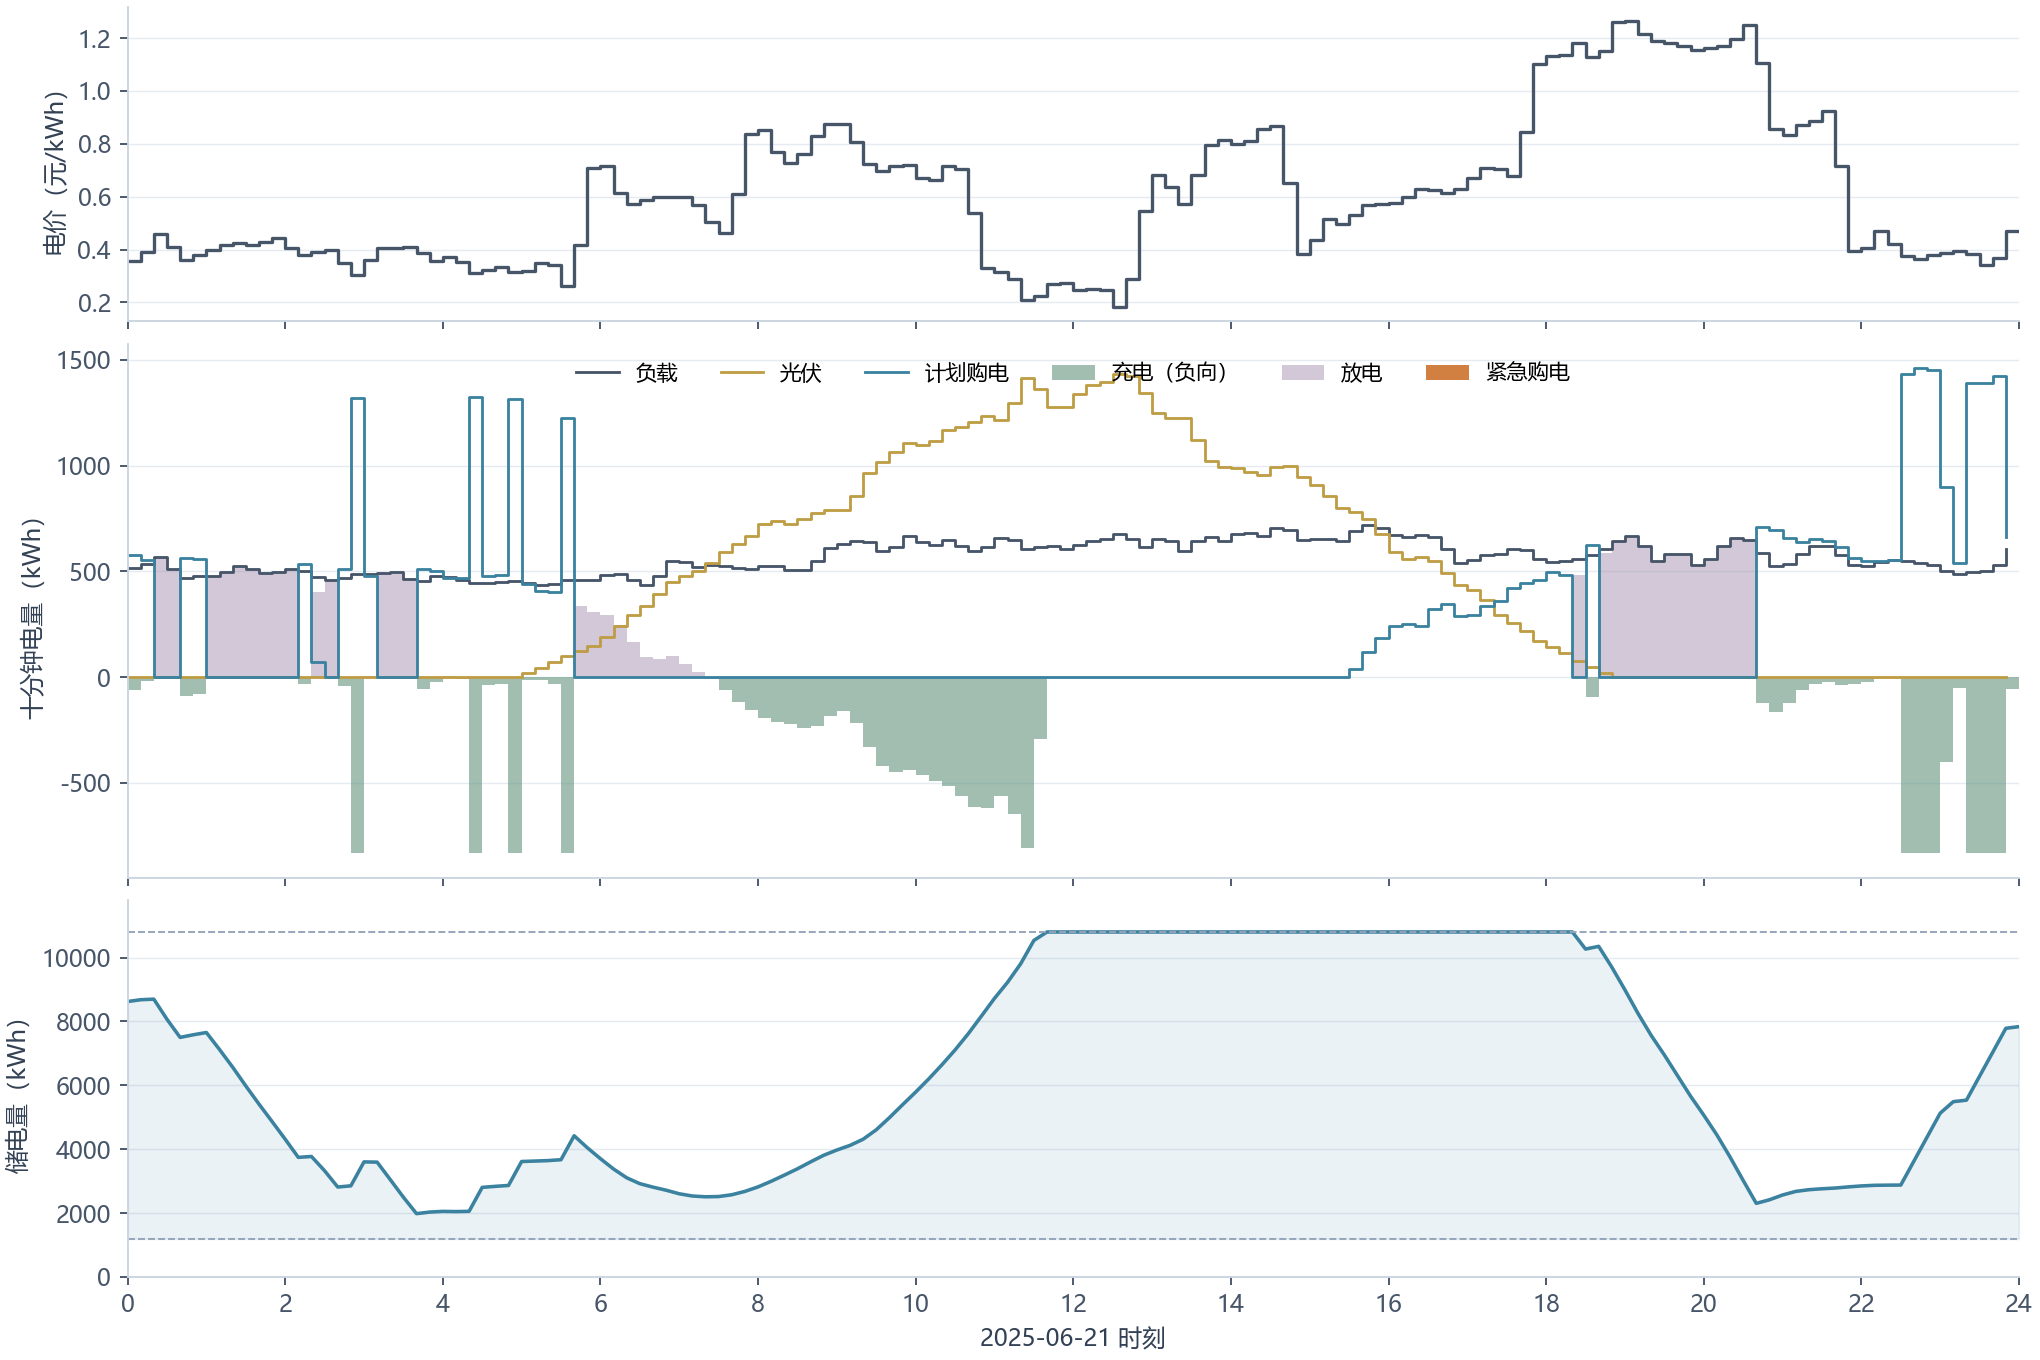

In [20]:
plot_dispatch(data,FIGURES,'2025-06-21','dispatch_june21')
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'dispatch_june21.png')))

## 紧急电量最高日：仅作事后诊断

压力日： 2025-06-01


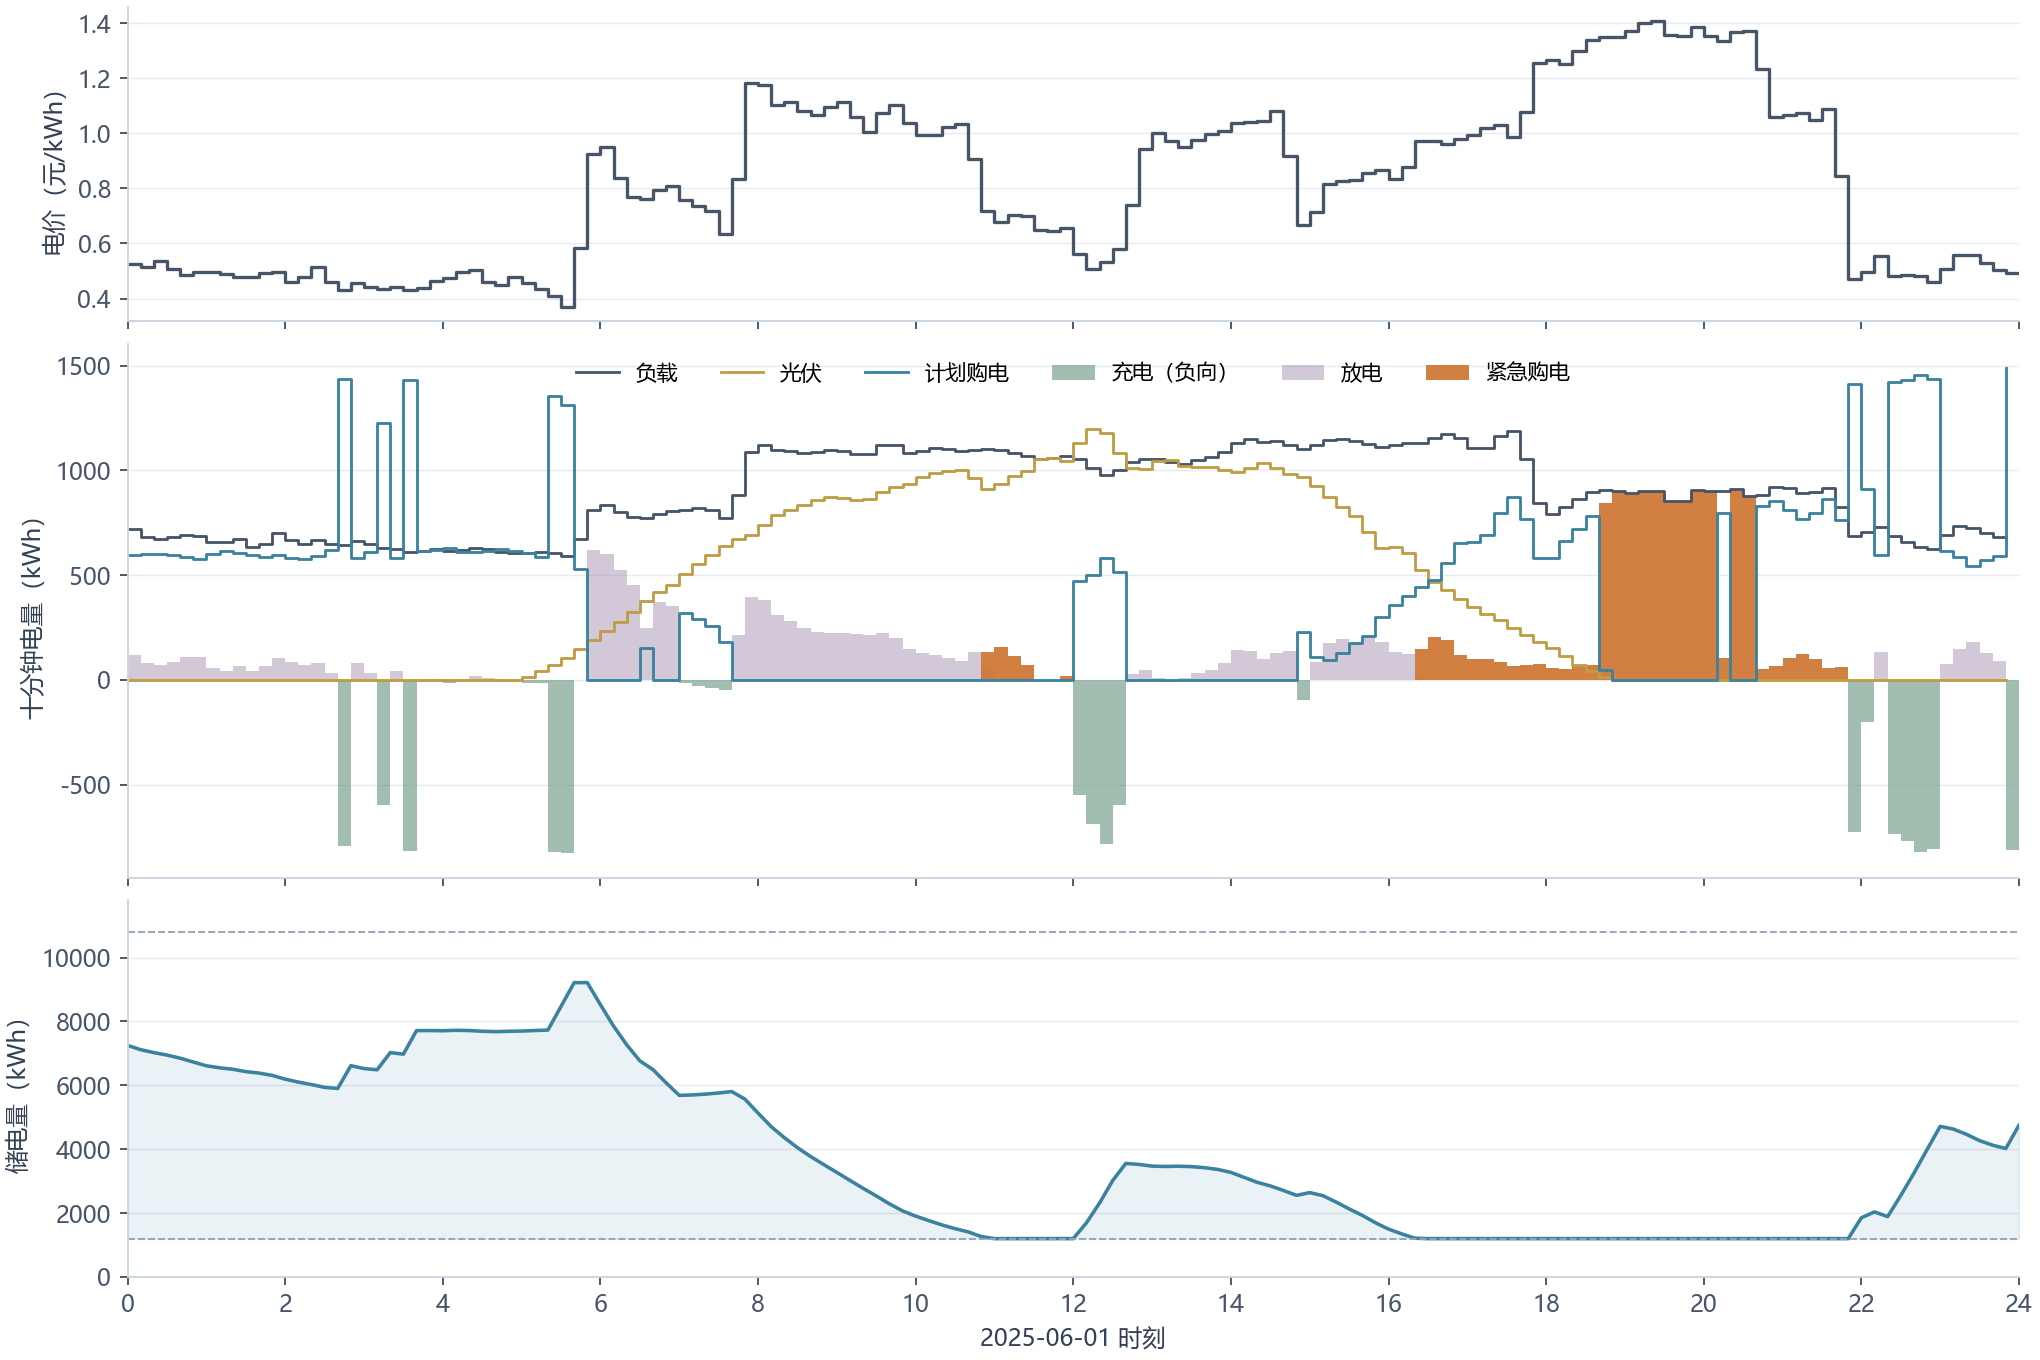

In [21]:
stress=data['dispatch'].groupby('date').emergency_kwh.sum().idxmax()
print('压力日：',stress)
plot_dispatch(data,FIGURES,stress,'dispatch_stress_day')
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'dispatch_stress_day.png')))

## 库存范围及边界

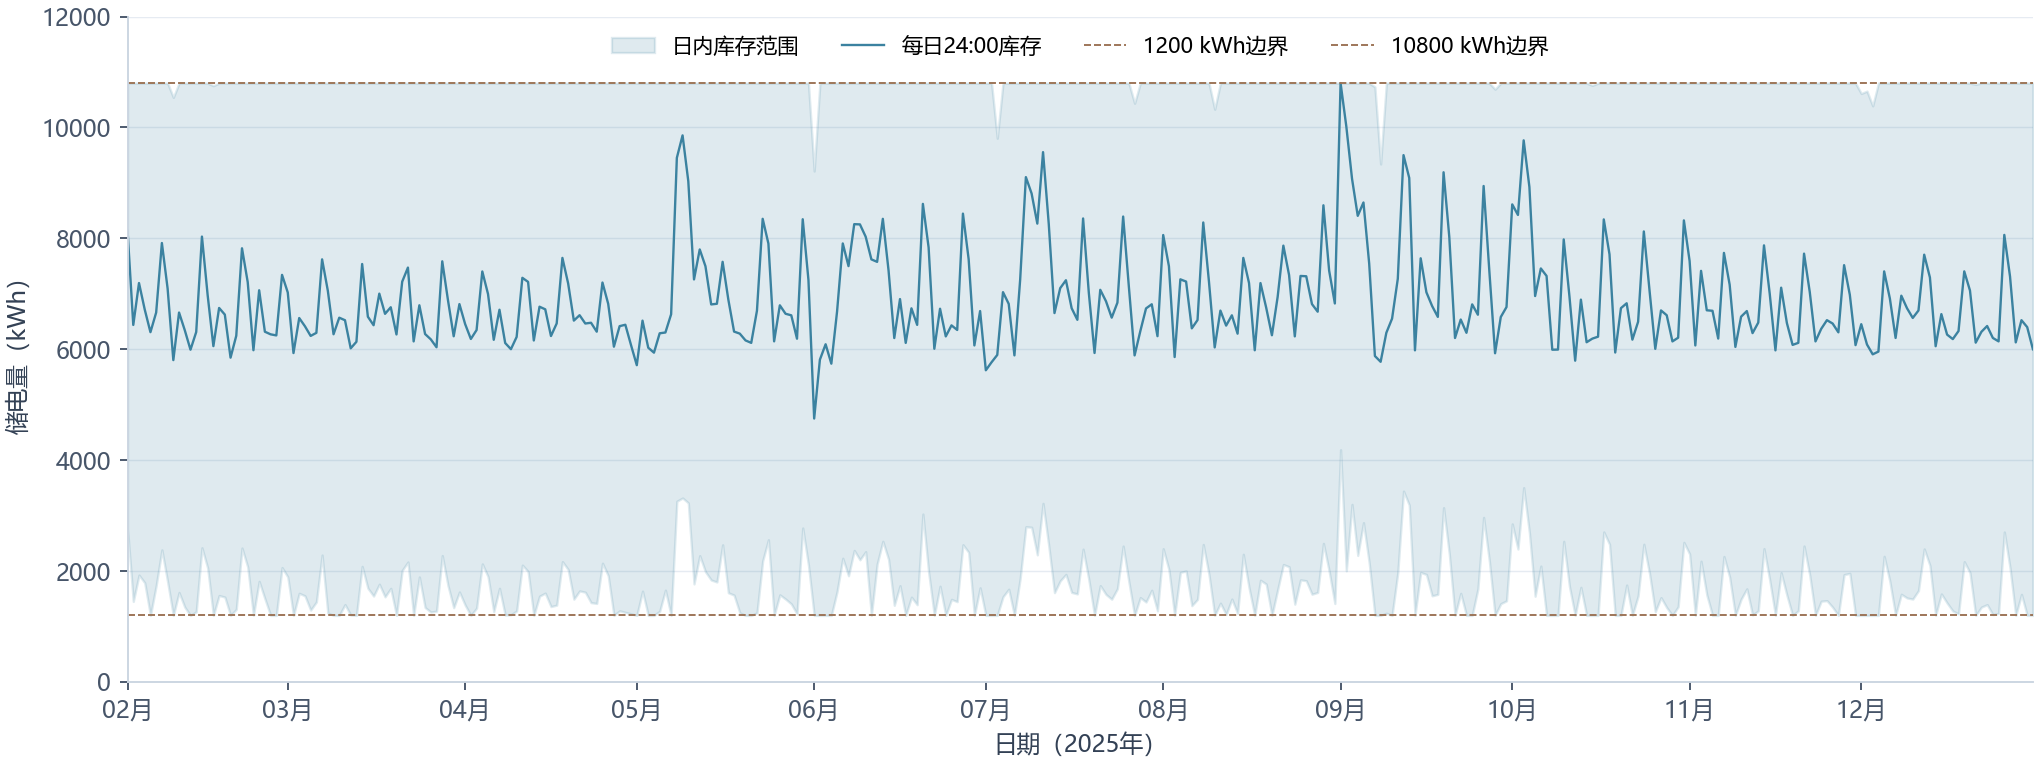

In [22]:
plot_soc(data,FIGURES)
from IPython.display import Image,display
display(Image(filename=str(FIGURES/'soc.png')))